## Predicting nashville Airbnb Prices Using ML

### 1. Problem Definition 

Given the Airbnb parameters, can we predict a right price range of an Airbnb? 

### 2. Data  

https://insideairbnb.com/get-the-data/

### 3. Evaluation 

Our Hope is to minimize size and distribution of prediction errors as possible as it could get using regression models

### 4. Features

* property_category: Type of property being rented (e.g., apartment, house).  
* room_type: Type of space offered (entire home, private room, etc.). 
* neighbourhood: Area where the listing is located.                       
* latitude: Latitude coordinate of the listing.                      
* longitude: Longitude coordinate of the listing.                     
* accommodates: Maximum number of guests the property can host.          
* bedrooms: Number of bedrooms in the property.                      
* beds: Number of beds available.                                
* bathrooms: Number of bathrooms in the property.                     
* price: Nightly rental price of the listing.                     
* estimated_annual_revenue: Estimated yearly income generated by the listing.       
* estimated_annual_occupancy: Estimated number of occupied nights per year.            
* host_experience_years: Number of years the host has been on Airbnb.             
* host_listing_count: Total number of listings managed by the host.            
* host_identity_verified: Indicates whether the host's identity is verified.       
* host_is_superhost: Indicates whether the host has Superhost status.         
* host_response_time: Typical time taken by the host to respond.               
* host_response_rate: Percentage of guest inquiries the host responds to.      
* host_acceptance_rate: Percentage of booking requests the host accepts.         
* instant_bookable: Indicates whether guests can book instantly.             
* amenity_count: Total number of amenities provided.                      
* has_pool: Indicates whether the property has a pool.               
* has_gym: Indicates whether the property has a gym.                
* has_free_parking: Indicates whether free parking is available.             
* total_reviews: Total number of guest reviews received.                  
* monthly_review: Average number of reviews received per month.            
* reviews_per_month: Average monthly review frequency.                        
* rating: Overall guest rating of the listing.                     
* cleanliness_rating: Guest rating for cleanliness.                            
* location_rating: Guest rating for location.                               
* minimum_nights: Minimum number of nights required per booking.           
* maximum_nights: Maximum number of nights allowed per booking.            
* availability_monthly: Number of available days in the next 30 days.            
* availability_year: Number of available days in the next 365 days.           

### 5. EDA

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv('nashville_tennessee II.txt')
pd.set_option('display.max_columns', None)
df.head()

,id,property_category,room_type,neighbourhood,latitude,longitude,accommodates,bedrooms,beds,bathrooms,price,estimated_annual_revenue,estimated_annual_occupancy,host_experience_years,host_listing_count,host_identity_verified,host_is_superhost,host_response_time,host_response_rate,host_acceptance_rate,instant_bookable,amenity_count,has_pool,has_gym,has_free_parking,number_of_reviews,monthly_review,reviews_per_month,rating,cleanliness_rating,location_rating,minimum_nights,maximum_nights,availability_monthly,availability_year
0,6422,Private room,Private room,District 6,36.17143,-86.73570,1,1.0,1.0,1.0,43.0,0.0,0,17.25,1,True,False,within a day,1.0,1.00,False,52,False,False,False,667,0,3.34,4.95,4.96,4.92,30,365,0,175
1,39870,Private room,Private room,District 25,36.12466,-86.81269,2,1.0,1.0,1.0,70.0,17850.0,255,15.96,2,True,True,within an hour,1.0,0.91,False,27,False,False,True,587,80,5.34,4.93,4.91,4.93,1,7,17,242
2,72906,Entire rental unit,Entire home/apt,District 18,36.13122,-86.80066,2,2.0,2.0,1.0,91.0,18564.0,204,15.95,1,True,True,within an hour,1.0,0.96,False,42,False,False,False,777,34,4.46,4.92,4.83,4.97,2,7,8,234
3,258817,Private room,Private room,District 12,36.16076,-86.59151,2,1.0,2.0,1.0,34.0,0.0,0,17.03,25,True,False,within an hour,1.0,1.00,False,33,False,False,True,97,0,0.58,4.78,4.41,4.74,30,365,29,364
4,289242,Private room,Private room,District 12,36.16296,-86.59113,1,2.0,2.0,1.0,33.0,0.0,0,17.03,25,True,False,within an hour,1.0,1.00,False,31,False,False,True,76,0,0.45,4.71,4.27,4.47,30,365,30,365


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6628 entries, 0 to 6627
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          6628 non-null   int64  
 1   property_category           6628 non-null   object 
 2   room_type                   6628 non-null   object 
 3   neighbourhood               6628 non-null   object 
 4   latitude                    6628 non-null   float64
 5   longitude                   6628 non-null   float64
 6   accommodates                6628 non-null   int64  
 7   bedrooms                    6628 non-null   float64
 8   beds                        6628 non-null   float64
 9   bathrooms                   6628 non-null   float64
 10  price                       6628 non-null   float64
 11  estimated_annual_revenue    6628 non-null   float64
 12  estimated_annual_occupancy  6628 non-null   int64  
 13  host_experience_years       6628 

In [4]:
df.describe()

,id,latitude,longitude,accommodates,bedrooms,beds,bathrooms,price,estimated_annual_revenue,estimated_annual_occupancy,host_experience_years,host_listing_count,host_response_rate,host_acceptance_rate,amenity_count,number_of_reviews,monthly_review,reviews_per_month,rating,cleanliness_rating,location_rating,minimum_nights,maximum_nights,availability_monthly,availability_year
count,6.628000e+03,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6.628000e+03,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000,6628.000000
mean,6.919970e+17,36.163590,-86.767339,6.899819,2.411587,4.282740,2.171620,219.923808,2.323387e+04,121.738986,8.299119,102.253319,0.989810,0.958882,45.224049,100.082227,22.287266,2.369403,4.506148,4.485136,4.434268,5.432559,436.788926,14.119342,262.843241
std,5.789478e+17,0.042585,0.052994,3.824967,1.624711,3.782014,1.547353,675.533334,5.386398e+04,89.275310,3.535675,305.986412,0.064839,0.137218,13.855025,152.739370,28.899891,2.647130,1.297928,1.293165,1.285140,12.298074,393.829456,7.945364,98.753213
min,6.422000e+03,35.984890,-87.035960,1.000000,0.000000,0.000000,0.000000,22.000000,0.000000e+00,0.000000,0.790000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,4.355216e+07,36.144385,-86.795590,4.000000,1.000000,2.000000,1.000000,109.000000,6.300000e+03,42.000000,5.390000,2.000000,1.000000,0.980000,37.000000,11.000000,4.000000,0.800000,4.800000,4.750000,4.660000,1.000000,89.000000,9.000000,207.000000
50%,8.116695e+17,36.159060,-86.775728,6.000000,2.000000,3.000000,2.000000,158.000000,1.764000e+04,114.000000,9.070000,9.000000,1.000000,1.000000,46.000000,47.000000,17.000000,2.000000,4.910000,4.890000,4.850000,2.000000,365.000000,14.000000,307.000000
75%,1.240095e+18,36.186605,-86.744948,10.000000,3.000000,6.000000,3.000000,236.000000,3.133350e+04,198.000000,10.810000,72.000000,1.000000,1.000000,55.000000,128.000000,32.000000,3.290000,4.980000,4.970000,4.940000,2.000000,365.000000,19.000000,341.000000
max,1.516029e+18,36.396700,-86.552100,16.000000,48.000000,96.000000,50.000000,50000.000000,3.900000e+06,255.000000,17.250000,9702.000000,1.000000,1.000000,93.000000,3427.000000,1140.000000,76.420000,5.000000,5.000000,5.000000,365.000000,1125.000000,30.000000,365.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum().sum()

np.int64(0)

#### 5.1 Visuals

Price skewness: 61.780120849711665


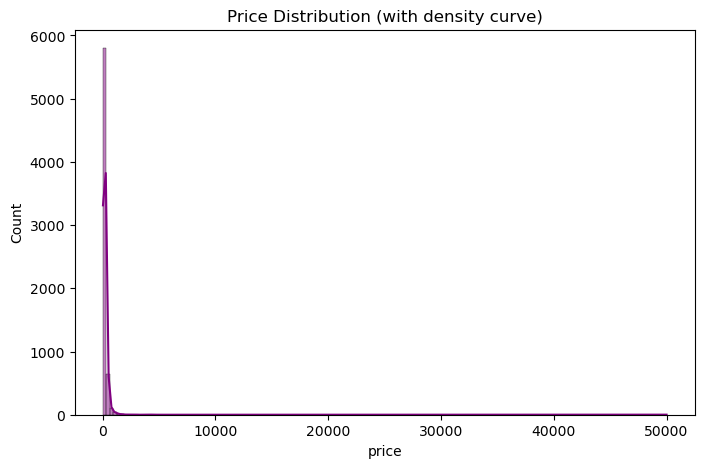

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='purple')
plt.title('Price Distribution (with density curve)')
print("Price skewness:", df['price'].skew())

In [8]:
df = df[df["price"] != 50000]

* raw price is brutally right-skewed (median 158, but max is 50,000), so a handful of extreme outliers/luxury listings are dragging the tail. strong signal to train on log1p(price)
* more visuals were done in visual and storytelling notebook. refer for more.

### 6. Data Preprocessing 

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [10]:
# keep id aside, drop leakage column

df = df.drop(columns=['id', 'estimated_annual_revenue'])

X = df.drop(columns=['price'])
y = np.log1p(df['price'])

bool_cols = X.select_dtypes(include='bool').columns.tolist()
X[bool_cols] = X[bool_cols].astype(int)

cat_cols = ['property_category', 'room_type', 'neighbourhood', 'host_response_time']

skewed_num = ['bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'monthly_review',
              'reviews_per_month', 'host_listing_count', 'minimum_nights', 'maximum_nights']

normal_num = ['accommodates', 'latitude', 'longitude', 'host_experience_years',
              'host_response_rate', 'host_acceptance_rate', 'amenity_count', 'rating',
              'cleanliness_rating', 'location_rating', 'availability_monthly',
              'availability_year', 'estimated_annual_occupancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_scale = Pipeline([
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scale', RobustScaler())
])

In [11]:
preprocessor = ColumnTransformer([
    ('skewed', log_scale, skewed_num),
    ('normal', StandardScaler(), normal_num),
    ('bool', 'passthrough', bool_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_cols),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

droppped columns 
   * id — pure identifier, no predictive value, but keep it around for traceability/joins.
   * estimated_annual_revenue — leakage, explained above.

### 7. Regression Models, Evaluations, & Comparisions

In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.utils import resample
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import time

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.01, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'Extra_tree': ExtraTreesRegressor(random_state=42),
    'Adaboost': AdaBoostRegressor(random_state=42),
    'Lightgbm': LGBMRegressor(random_state=42),
    'Catboost': CatBoostRegressor(random_state=42, verbose=0) 
}

trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_processed, y_train)
    trained_models[name] = model
    print(f"{name} trained in {time.time() - start:.1f} sec")

Linear Regression trained in 0.5 sec
Ridge Regression trained in 0.0 sec
Lasso Regression trained in 0.3 sec
Decision Tree trained in 0.3 sec
Random Forest trained in 20.4 sec
Gradient Boosting trained in 4.7 sec
XGBoost trained in 0.6 sec
Extra_tree trained in 13.1 sec
Adaboost trained in 2.2 sec
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2416
[LightGBM] [Info] Number of data points in the train set: 5301, number of used features: 74
[LightGBM] [Info] Start training from score 5.115906
Lightgbm trained in 2.5 sec
Catboost trained in 7.8 sec


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

# convert true test values back to real price once
y_test_actual = np.expm1(y_test)

for name, model in trained_models.items():
    y_pred_log = model.predict(X_test_processed)
    y_pred_actual = np.expm1(y_pred_log)  # back to real dollars

    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_actual)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df)

                Model        MAE           MSE        RMSE        R2
0            Catboost  50.667750   9874.458436   99.370310  0.696328
1            Lightgbm  52.104969  10018.473424  100.092325  0.691899
2             XGBoost  53.289778  11076.603280  105.245443  0.659358
3       Random Forest  55.606556  12382.466215  111.276530  0.619198
4          Extra_tree  53.767711  12762.301089  112.970355  0.607517
5   Gradient Boosting  61.212756  14333.170549  119.721220  0.559208
6   Linear Regression  67.951469  16731.947700  129.352030  0.485438
7    Ridge Regression  67.955926  16745.107451  129.402888  0.485033
8            Adaboost  83.702164  17831.952941  133.536336  0.451609
9    Lasso Regression  71.914506  19616.463860  140.058787  0.396729
10      Decision Tree  85.795626  61244.976621  247.477224 -0.883484


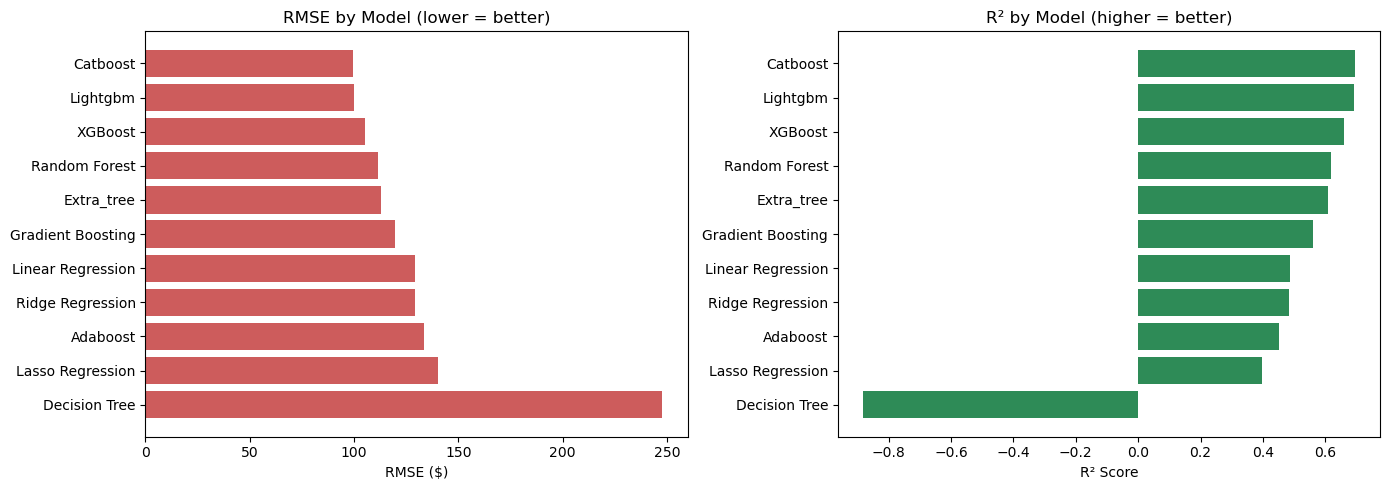

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df['Model'], results_df['RMSE'], color='indianred')
axes[0].set_xlabel('RMSE ($)')
axes[0].set_title('RMSE by Model (lower = better)')
axes[0].invert_yaxis()

axes[1].barh(results_df['Model'], results_df['R2'], color='seagreen')
axes[1].set_xlabel('R² Score')
axes[1].set_title('R² by Model (higher = better)')
axes[1].invert_yaxis()

plt.tight_layout()

### 8. Experimenting 

In [31]:
from sklearn.model_selection import RandomizedSearchCV
cat_param_dist = {
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.1, 0.2],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "iterations": [500, 1000, 1500]
}

cat_search = RandomizedSearchCV(
    estimator=CatBoostRegressor(random_state=42, verbose=0),
    param_distributions=cat_param_dist,
    n_iter=10,  # Tries 15 random combinations
    cv=3,       # 3-fold cross-validation
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

# Remember to tune on the LOG-transformed target (y_train), not the actual dollars!
cat_search.fit(X_train_processed, y_train)
best_cat_model = cat_search.best_estimator_
print(f"Best CatBoost Params: {cat_search.best_params_}\n")

Best CatBoost Params: {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 6}



In [30]:
lgb_param_dist = {
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 5, 8, 12],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [500, 800, 1000],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}
lgb_search = RandomizedSearchCV(
    estimator= LGBMRegressor(random_state=42),
    param_distributions=lgb_param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgb_search.fit(X_train_processed, y_train)
best_lgb_model = lgb_search.best_estimator_
print(f"Best LightGBM Params: {lgb_search.best_params_}\n")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002784 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2416
[LightGBM] [Info] Number of data points in the train set: 5301, number of used features: 74
[LightGBM] [Info] Start training from score 5.115906
Best LightGBM Params: {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 800, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.6}



In [33]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,             # number of random combinations to try
    scoring='neg_mean_squared_error',
    cv=5,                
    verbose=2,
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

xgb_search.fit(X_train_processed, y_train)

print("Best params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [34]:
tuned_models = {
    'catBoost (Tuned)': cat_search.best_estimator_,
    'lightgbm (Tuned)': lgb_search.best_estimator_,
    'XGBoost (Tuned)': xgb_search.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred_log = model.predict(X_test_processed)
    y_pred_actual = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_actual)

    tuned_results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values('R2', ascending=False).reset_index(drop=True)
print(tuned_results_df)

              Model        MAE           MSE        RMSE        R2
0  lightgbm (Tuned)  49.652627   9323.856931   96.560121  0.713261
1  catBoost (Tuned)  50.457266  10273.707688  101.359300  0.684050
2   XGBoost (Tuned)  51.665698  10385.564622  101.909590  0.680610


### 9. Model Selection and Saving 

In [36]:
import joblib

# Save the final tuned XGBoost model
joblib.dump(lgb_search.best_estimator_, 'airbnb_price_model.pkl')

# Save the preprocessor (scaler + encoder) used to transform features
joblib.dump(preprocessor, 'airbnb_price_preprocessor.pkl')

print("Model and preprocessor saved.")

Model and preprocessor saved.
